Problem: We can not do a naive Singular value decomposition of the boudary operator $$ \Lambda_\gamma : H^{-1/2}(\partial\Omega) \rightarrow H^{1/2}(\partial\Omega) $$

This is because the decomposition needs us to take into account the scalar products of the domain & image of the operator.
It turns out that the SVD is:
$$ \Lambda_\gamma = M_{H^{-1/2}(\partial\Omega)} U^T \Sigma V M_{H^{1/2}(\partial\Omega)} $$
Which is why we went through the hassle of computing the required mass matrices for the fractional boundary spaces.

In [1]:
#Actually that is bullshit
#It worked way easier. 
#I just forgot that I need to use Moore-Penrose inverse and not just transpose the matrix of G the boundary current patterns

In [2]:
using Ferrite
using ModularEIT
using Images
using IterativeSolvers
using LinearAlgebra


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [3]:
σf = 1.0e-2 # how much noise is added to f
σg = 1.0e-2 # How much noise is added to g

0.01

In [4]:
img = load("../reconstructions/1096.jpg")
itp = interpolate_array_2D(Float64.(img))
n = 63 
grid = generate_grid(Quadrilateral, (n, n));
∂Ω = union(getfacetset.((grid,), ["left", "top", "right", "bottom"])...)
fe  = FerriteFESpace{RefQuadrilateral}(grid,2,3,∂Ω)
cond_vec = project_function_to_fem(fe, itp)
cond_vec .= min.(max.(cond_vec,1e-6),1.0)
G_full = real_fourier_basis(8)
rhs_dict = Dict()
Threads.@threads for i in 2:256
    M = make_boundary(G_full[:, i],64)
    itp = interpolate_array_2D(M)
    rhs_dict[i] = assemble_rhs_func(fe, itp)
end

In [5]:
K = assemble_L(fe, cond_vec)
K_fac = cholesky(K)
mode_dict = Dict{Int64,FerriteEITMode}()
mode_dict_no_noise = Dict{Int64,FerriteEITMode}()
@time begin
    Threads.@threads for i in 2:256
        mode_dict[i-1] = create_mode_from_g(fe, rhs_dict[i], K_fac, normalize =  true, σ_f = σf, σ_g= σg)
        mode_dict_no_noise[i-1] = create_mode_from_g(fe, rhs_dict[i], K_fac, normalize =  true)
    end
end

  1.252592 seconds (1.10 M allocations: 910.567 MiB, 37.27% gc time, 22.68% compilation time)


In [6]:
_,_, Hn12, H12 = assemble_boundary_matrices!(fe)
eig = fe.BDO.eig

GeneralizedEigen{Float64, Float64, Matrix{Float64}, Vector{Float64}}
values:
504-element Vector{Float64}:
  6801.077429376347
  6801.07742937642
  6801.077429376424
  6801.077429376465
  8932.728242800937
  8932.77466228132
  8932.774662281327
  8932.822397431755
  8940.16308492843
  8940.348501419117
     ⋮
 68274.47566312845
 68408.58575097671
 68413.29658653359
 68413.2965865336
 68417.44596970722
 72948.32856778351
 72948.32856778847
 72948.32856778853
 72948.32856779352
vectors:
504×504 Matrix{Float64}:
 -1.85355e-21  -5.43676e-8   …  -0.0483281     5.12686    3.79395
  1.51179e-21  -1.34739e-8      -0.0360568     3.82507    2.83061
 -3.03367e-21  -1.34739e-8      -0.0360568     3.82507    2.83061
  5.51719e-23  -3.66984e-8       0.0232248    -2.46379   -1.82324
  1.67095e-21  -3.66984e-8       0.0232248    -2.46379   -1.82324
  4.31876e-21  -3.13023e-9   …  -0.0227817     2.41678    1.78845
 -1.54528e-21  -6.46866e-9       0.0141001    -1.4958    -1.10692
  5.56377e-21  -7.27204e

In [7]:
H12

504×504 Symmetric{Float64, Matrix{Float64}}:
  1.23384      -0.083902     -0.083902     …   9.25015e-17  -4.56041e-17
 -0.083902      1.31144      -0.0161238        1.54629e-16   1.26668e-17
 -0.083902     -0.0161238     1.31144         -8.3543e-17   -2.41255e-17
 -0.226306     -0.0743961     0.0659812       -1.43994e-16  -1.29178e-16
 -0.226306      0.0659812    -0.0743961       -7.69336e-17   6.29773e-17
 -0.00441946   -0.113864      9.93867e-5   …  -1.10432e-16   8.35728e-18
  0.0180074    -0.0488927    -0.000451889      1.08524e-17  -4.27197e-17
 -0.000425545  -0.00313222    6.81773e-6      -3.14651e-16  -5.40091e-17
  0.001516      0.0125316    -2.9927e-5        1.80817e-16  -1.21274e-17
 -4.63779e-5   -0.000304288   4.52647e-7      -1.77242e-17   1.79653e-17
  ⋮                                        ⋱                
  2.80797e-16  -1.51177e-16   1.8615e-17   …  -4.36093e-5    0.00123327
 -6.69816e-18  -9.82397e-18  -1.95485e-16      1.40343e-5   -0.000440389
 -1.31582e-16   1.4

Now we can attempt an SVD on the dictionaries

In [8]:
G = hcat([mode_dict_no_noise[i].g for i in 1:255]...)
F = hcat([mode_dict_no_noise[i].f for i in 1:255]...)

504×255 Matrix{Float64}:
  1034.77  -400.909    24.4879   …    16.397      1.57838     10.2555
  1027.16  -400.316    16.8068        -7.33188    1.74001     -6.5287
  1027.24  -401.507    17.0171        -7.46544    1.41463     -6.62318
  1030.94  -400.741    20.6381         1.30802    1.70667     -0.4183
  1030.97  -401.078    20.7079         1.29451    1.44932     -0.427869
  1019.8   -398.878     9.24361  …     7.95013    1.19881      4.28865
  1023.44  -399.688    13.004          0.72537    1.3723      -0.823014
  1012.48  -396.724     1.55368       -7.75029    2.1404      -6.83589
  1016.17  -397.884     5.45555       -0.72485    1.80075     -1.86162
  1005.05  -394.006    -6.39351        7.89686    0.835888     4.27098
     ⋮                           ⋱                          
 -3779.13  -491.409  3786.11     …   510.369    -32.6731    -363.389
 -3546.16  -506.187  3555.64         -25.5682    13.0389      17.1444
 -3995.18  -454.156  4000.28        -371.237     21.2289     261.3

In [9]:
Λ = F * pinv(G)

504×504 Matrix{Float64}:
  3.87817   1.81294   1.81539   5.67402  …   -2.24909   -4.23201   -4.30775
  2.04107   2.79568   2.08237   4.85115      -2.24557   -4.22497   -4.30071
  2.03891   2.08326   2.81033   4.12544      -2.24553   -4.22489   -4.30063
  2.83626   2.41944   2.0411    5.25796      -2.24731   -4.22845   -4.30419
  2.83828   2.03923   2.42462   4.87308      -2.2473    -4.22844   -4.30418
  1.8769    1.70143   1.74199   3.56946  …   -2.24225   -4.21832   -4.29406
  1.87372   2.29559   1.92611   4.17275      -2.24388   -4.22159   -4.29733
  1.5637    1.67978   1.58308   3.24537      -2.23903   -4.21188   -4.28762
  1.72524   1.63392   1.64947   3.35442      -2.24064   -4.21512   -4.29086
  1.44291   1.4249    1.42249   2.86647      -2.23584   -4.20552   -4.28126
  ⋮                                      ⋱                        
 -1.75984  -1.75511  -1.75511  -3.51493  …   18.8176    40.1723    45.3479
 -1.65047  -1.64574  -1.64573  -3.29617      17.4364    35.8281    37.909

In [10]:
norm(Λ * mode_dict[255].g - mode_dict[255].f, Inf)

9.473428659966771

In [11]:
V,Σ, U =  svd(Λ)

SVD{Float64, Float64, Matrix{Float64}, Vector{Float64}}
U factor:
504×504 Matrix{Float64}:
 -0.0142113  0.000359497  -0.03026    …   0.0757718    0.0551689
 -0.0141794  0.000359553  -0.0301287      0.038688     0.0656638
 -0.0141779  0.000356723  -0.0301373     -0.0629095   -0.0184863
 -0.014195   0.000359167  -0.0301948     -0.101865    -0.0551506
 -0.0141947  0.00035846   -0.0301973     -0.0459352   -0.0849281
 -0.0141503  0.000362457  -0.0299946  …   0.0170139    0.018354
 -0.0141645  0.000360648  -0.0300618      0.0350487   -0.06307
 -0.0141234  0.000368324  -0.0298536      0.0828006   -0.0599766
 -0.0141368  0.000365018  -0.0299257     -0.0921271    0.0172481
 -0.0140978  0.000377014  -0.0297041      0.00398037  -0.0355281
  ⋮                                   ⋱               
  0.147677   0.0475969     0.0170574  …  -0.0338889   -0.00420278
  0.135418   0.041348      0.0128896      0.0426492    0.00180084
  0.161167   0.0549512     0.0228414     -0.0330997    0.0465399
  0.153893

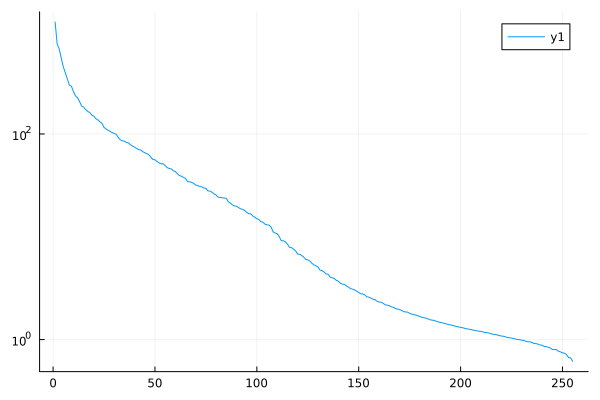

In [12]:
using Plots
plot(Σ[1:255],yscale=:log10)
#plot(Σ[1:255])

In [13]:
Σdiag = Diagonal(Σ[1:255])
Fnew = V[:,1:255]*Σdiag
Gnew = U[:,1:255]
n1 = 200
n2 = 12
fn1 = Fnew[:,n1]
gn1 = Gnew[:,n1]
fn2 = Fnew[:,n2]
gn2 = Gnew[:,n2]

504-element Vector{Float64}:
 -0.0016781732110513266
 -0.001649108955187606
 -0.0016511182152256065
 -0.003325804487021633
 -0.0033277702110666926
 -0.0016277566100611623
 -0.003275603059938778
 -0.0016003418127523428
 -0.0032266239764298724
 -0.0015714291203183933
  ⋮
 -0.0005529828896739956
 -0.0010234940494472928
 -0.009896499159085036
 -0.010234051267277429
 -0.01910066477527642
 -0.02922488159810126
 -0.05738362732567881
 -0.06311850904454563
 -0.0762556821334237

In [14]:
diff = fe.down(K \ fe.up(gn1)) - fn1
diff.-= mean(diff)
norm(diff)

2.0840270668802952e-12

In [15]:
diff = fe.down(K \ fe.up(0.6*gn2+0.4*gn1)) - (0.6*fn2+0.4*fn1)
diff.-= mean(diff)
norm(diff)

9.174348133657598e-13

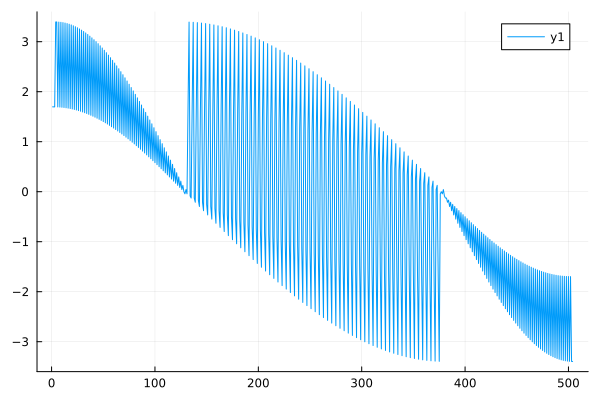

In [16]:
plot(G[:,1])

In [17]:
mode_dict_svd = Dict{Int64,FerriteEITMode}()
@time begin
    Threads.@threads for i in 1:255
        mode_dict_svd[i] = create_mode_from_fg(fe,Fnew[:,i],Gnew[:,i])
    end
end

  0.182784 seconds (139.21 k allocations: 294.018 MiB, 12.66% gc time, 42.47% compilation time)


In [18]:
function svd_on_modes(modes::Dict{Int64,FerriteEITMode},fe::FerriteFESpace)
    n = length(modes)
    G = hcat([mode_dict_no_noise[i].g for i in 1:n]...)
    F = hcat([mode_dict_no_noise[i].f for i in 1:n]...)
    Λ = F * pinv(G)
    V,Σ, U =  svd(Λ)
    Σdiag = Diagonal(Σ[1:n])
    Fnew = V[:,1:n]*Σdiag
    Gnew = U[:,1:n]
    mode_dict_svd = Dict{Int64,FerriteEITMode}()
    @time begin
        Threads.@threads for i in 1:n
            mode_dict_svd[i] = create_mode_from_fg(fe,Fnew[:,i],Gnew[:,i])
        end
    end
    mode_dict_svd, Σ[1:n]
end

svd_on_modes (generic function with 1 method)

In [19]:
mode_svd_noise, _ = svd_on_modes(mode_dict,fe)

  0.172493 seconds (69.67 k allocations: 290.680 MiB, 17.73% gc time, 35.54% compilation time)


(Dict{Int64, FerriteEITMode}(56 => FerriteEITMode([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.019450787717901947, 0.018250646424164914, 0.0, 0.01831052630333508, 0.018848455446156733, 0.0, 0.0, 0.018866313394752022, 0.0, 0.01706176040496903  …  0.03805473625404647, 0.0, 0.005685631907991221, 0.0, -0.017689014528392284, 0.0, -0.006864257784292855, 0.007432576473558846, 0.004231940363431105, 0.0], [0.019450787

In [20]:
σ_vec = 0.5* ones(fe.n)
sol = FerriteSolverState(fe, σ_vec)
prblm = FerriteProblem(fe, mode_svd_noise, sol)

FerriteProblem(FerriteFESpace{RefQuadrilateral}(CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 2}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}(Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 2}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}(Lagrange{RefQuadrilateral, 2}(), [0.47237900077244527 -1.4605338811812958e-17 … 1.8551212633834227e-18 0.007620999227554982; -0.05999999999999999 1.4605338811812958e-17 … -1.8551212633834227e-18 -0.059999999999999984; … ; 0.2749193338482966 -8.50014503228635e-18 … -8.500145032286352e-18 -0.03491933384829665; 0.15999999999999984 0.3999999999999998 … 0.3999999999999999 0.15999999999999992], [0.47237900077244527 -1.4605338811812958e-17 … 1.855121263383

In [21]:
eval_points = reshape(equidistant_grid(64), :)
ph = PointEvalHandler(grid, eval_points)

PointEvalHandler{Grid{2, Quadrilateral, Float64}, Float64}
  number of points: 4096
  Found corresponding cell for all points.

In [22]:
f,∂f = create_f∂f(prblm, 50)
prox_obj = create_prox_linesearch(f, ∂f, 0.0)

#create_prox_linesearch##0 (generic function with 2 methods)

In [23]:
σ_05 = 0.5*ones(fe.n)
σ₁ ,err1 = prox_obj(σ_05)
sum(abs2,σ₁- σ_05)

60.86499421323413

In [24]:
σᵢ = σ₁
for i in 1:20
    σᵢ ,erri = prox_obj(σᵢ)
    println("$i : $erri")
end

1 : 0.0002429818594489693
2 : 0.0002429818594489693
3 : 0.0002429818594489693
4 : 0.0002429818594489693
5 : 0.0002429818594489693
6 : 0.0002429818594489693
7 : 0.0002429818594489693
8 : 0.0002429818594489693
9 : 0.0002429818594489693
10 : 0.0002429818594489693
11 : 0.0002429818594489693
12 : 0.0002429818594489693
13 : 0.0002429818594489693
14 : 0.0002429818594489693
15 : 0.0002429818594489693
16 : 0.0002429818594489693
17 : 0.0002429818594489693
18 : 0.0002429818594489693
19 : 0.0002429818594489693
20 : 0.0002429818594489693


In [25]:
solution = Gray.(max.(min.(reshape(evaluate_at_points(ph, prblm.fe.dh, u),(64,64)),1.0),0.0))

UndefVarError: UndefVarError: `u` not defined in `Main`
Suggestion: check for spelling errors or missing imports.